TODO
- fazer scripts bonitinhos pra receber uma funcao, derivar, integrar...
- fazer plots 3d pra funcoes f(x,y)
- revisar listas


=== Cálculo de Derivadas e Integrais ===
1. Calcular Derivada
2. Calcular Integral
3. Sair

--- Derivação de Funções ---
Exemplos: x**2, sp.sin(x), sp.exp(x), sp.log(x)

Função original: x**3 + 2*x - 6
Derivada: 3*x**2 + 2
Derivada simplificada: 3*x**2 + 2


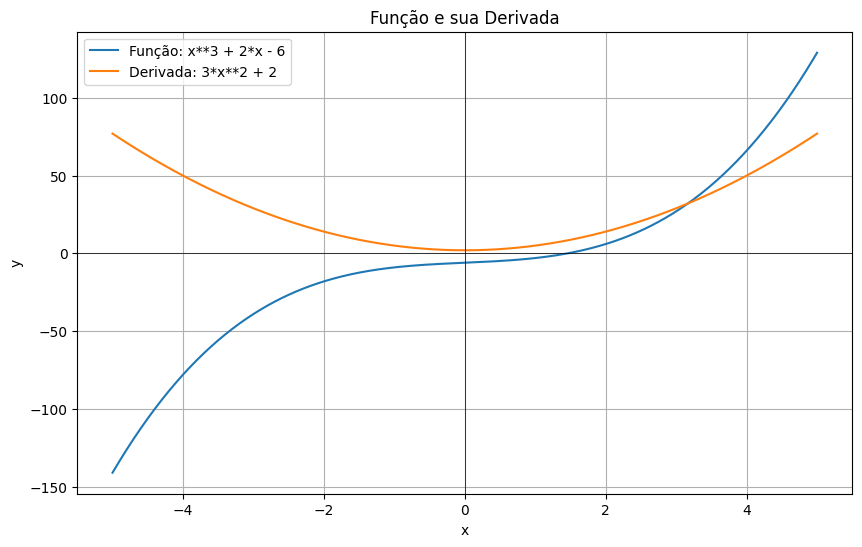


=== Cálculo de Derivadas e Integrais ===
1. Calcular Derivada
2. Calcular Integral
3. Sair
Saindo do programa...


In [1]:
import numpy as np
import sympy as sp
from scipy import integrate
import matplotlib.pyplot as plt

def derivar_funcao():
    """Calcula a derivada de uma função usando SymPy"""
    x = sp.symbols('x')
    print("\n--- Derivação de Funções ---")
    print("Exemplos: x**2, sp.sin(x), sp.exp(x), sp.log(x)")
    expr_str = input("Digite a função (use 'x' como variável e 'sp.' para funções especiais): ")
    
    try:
        # Avalia a string como uma expressão SymPy
        expr = eval(expr_str, {'sp': sp, 'x': x})
        
        # Calcula a derivada
        derivada = sp.diff(expr, x)
        
        print(f"\nFunção original: {expr}")
        print(f"Derivada: {derivada}")
        print(f"Derivada simplificada: {sp.simplify(derivada)}")
        
        # Plota a função e sua derivada
        plotar_funcao_e_derivada(expr, derivada)
        
    except Exception as e:
        print(f"\nErro ao processar a função: {e}")

def integrar_funcao():
    """Calcula a integral de uma função usando SymPy e SciPy para integração numérica"""
    x = sp.symbols('x')
    print("\n--- Integração de Funções ---")
    print("Exemplos: x**2, sp.sin(x), sp.exp(-x**2), 1/x")
    expr_str = input("Digite a função (use 'x' como variável e 'sp.' para funções especiais): ")
    
    try:
        # Avalia a string como uma expressão SymPy
        expr = eval(expr_str, {'sp': sp, 'x': x})
        
        # Calcula a integral indefinida
        integral_indefinida = sp.integrate(expr, x)
        
        # Calcula a integral definida (de 0 a 1 como exemplo)
        integral_definida = sp.integrate(expr, (x, 0, 1))
        
        print(f"\nFunção original: {expr}")
        print(f"Integral indefinida: {integral_indefinida} + C")
        print(f"Integral definida de 0 a 1: {integral_definida}")
        
        # Calcula numericamente a integral definida usando SciPy
        f = sp.lambdify(x, expr, 'numpy')
        resultado_numerico, erro = integrate.quad(f, 0, 1)
        
        print(f"\nResultado numérico (SciPy) de 0 a 1: {resultado_numerico}")
        print(f"Erro estimado: {erro}")
        
        # Plota a função e sua integral
        plotar_funcao_e_integral(expr, integral_indefinida)
        
    except Exception as e:
        print(f"\nErro ao processar a função: {e}")

def plotar_funcao_e_derivada(f, df):
    """Plota a função e sua derivada"""
    x_vals = np.linspace(-5, 5, 400)
    f_lambdified = sp.lambdify('x', f, 'numpy')
    df_lambdified = sp.lambdify('x', df, 'numpy')
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, f_lambdified(x_vals), label=f'Função: {f}')
    plt.plot(x_vals, df_lambdified(x_vals), label=f'Derivada: {df}')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True)
    plt.legend()
    plt.title('Função e sua Derivada')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

def plotar_funcao_e_integral(f, integral):
    """Plota a função e sua integral"""
    x_vals = np.linspace(-5, 5, 400)
    f_lambdified = sp.lambdify('x', f, 'numpy')
    
    # Para a integral, precisamos calcular a integral definida de um ponto fixo até x
    integral_def = sp.integrate(f, 'x')
    integral_lambdified = sp.lambdify('x', integral_def, 'numpy')
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, f_lambdified(x_vals), label=f'Função: {f}')
    plt.plot(x_vals, integral_lambdified(x_vals), label=f'Integral: {integral} + C')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True)
    plt.legend()
    plt.title('Função e sua Integral')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

def menu():
    """Exibe o menu principal"""
    while True:
        print("\n=== Cálculo de Derivadas e Integrais ===")
        print("1. Calcular Derivada")
        print("2. Calcular Integral")
        print("3. Sair")
        
        opcao = input("Escolha uma opção (1-3): ")
        
        if opcao == '1':
            derivar_funcao()
        elif opcao == '2':
            integrar_funcao()
        elif opcao == '3':
            print("Saindo do programa...")
            break
        else:
            print("Opção inválida. Tente novamente.")

if __name__ == "__main__":
    # Verifica se as bibliotecas necessárias estão instaladas
    try:
        import numpy
        import sympy
        from scipy import integrate
        import matplotlib
    except ImportError as e:
        print(f"Erro: {e}. Por favor, instale as bibliotecas necessárias.")
        print("Você pode instalá-las com: pip install numpy sympy scipy matplotlib")
    else:
        menu()